<a href="https://colab.research.google.com/github/ushak1984/DX703-advanced-ML-and-AI-Final-Project/blob/main/FinalProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HuffPost News Category Classification with DistilBERT

This project builds a multiclass NLP model to classify HuffPost news articles using article headlines and short descriptions.

The workflow includes data exploration, preprocessing, label refinement, class imbalance handling, DistilBERT fine-tuning, and model evaluation.



#### **Imports**


In [ ]:
# ============================================
# Install Dependencies
# ============================================
# Install NLP + deep learning libraries (quiet mode to reduce output)

!pip install transformers torch datasets -q

# ============================================
# Standard Libraries
# ============================================
import os                      # file & directory operations
import time                    # track training time
import random                  # reproducibility (random seeds)
from collections import Counter  # count label frequencies

# ============================================
# Data & Numerics
# ============================================
import numpy as np             # numerical arrays & math operations
import pandas as pd            # data manipulation (DataFrames)

# ============================================
# Visualization
# ============================================
import matplotlib.pyplot as plt   # plotting graphs
import seaborn as sns             # better-looking statistical plots


# ============================================
# ML & Evaluation
# ============================================
from sklearn.model_selection import train_test_split   # split dataset
from sklearn.utils.class_weight import compute_class_weight  # handle imbalance
from sklearn.metrics import f1_score, classification_report  # evaluation metrics
from sklearn.metrics import confusion_matrix


# ============================================
# PyTorch & HuggingFace (DistilBERT)
# ============================================
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
# HuggingFace components for NLP model
from transformers import (
    DistilBertTokenizerFast,                # converts text → tokens
    DistilBertForSequenceClassification,    # pretrained model for classification
    Trainer,                                # high-level training API (optional)
    TrainingArguments                       # training config
)
from transformers import DistilBertConfig

# HuggingFace dataset utilities
from datasets import load_dataset, DatasetDict
from datasets.features import ClassLabel

# ============================================
# Progress Tracking
# ============================================
from tqdm import tqdm             # progress bar for loops
from IPython.display import display   # nicely display outputs in notebook


# ============================================
# Reproducibility
# ============================================
RANDOM_SEED = 42 # Setting seeds ensures same results every run
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# ============================================
# Visualization Theme (Make plots look clean)
# ============================================
sns.set_theme(style="darkgrid")

# Customize matplotlib appearance
plt.rcParams['axes.titlesize']   = 12
plt.rcParams['axes.labelsize']   = 10
plt.rcParams['lines.linewidth']  = 2
plt.rcParams['lines.markersize'] = 5
plt.rcParams['axes.edgecolor']   = 'black'
plt.rcParams['xtick.color']      = 'black'
plt.rcParams['ytick.color']      = 'black'
plt.rcParams['ytick.labelsize']  = 9
plt.rcParams['xtick.labelsize']  = 9
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = '#f0f0f0'
plt.rcParams['grid.color']       = 'white'
plt.rcParams['grid.linewidth']   = 1.5
plt.rcParams['font.family']      = 'monospace'

# ============================================
# Global Constants (MODEL SETTINGS)
# ============================================
MAX_LEN       = 64      # covers 98.4% of articles without truncation
BATCH_SIZE    = 32      # training batch size
EPOCHS        = 25      # max epochs (early stopping will cut short)
LEARNING_RATE = 2e-5    # DistilBERT recommended LR
DROPOUT_RATE  = 0.3    # classification head dropout
WEIGHT_DECAY  = 0.01    # AdamW weight decay
#NUM_CLASSES   = len(label2id)     # after merging overlapping categories
MODEL_NAME    = "distilbert-base-uncased" #(pretrained checkpoint)

# ============================================
# Utility Functions
# ============================================
def format_hms(seconds: float) -> str:
    """Convert elapsed seconds to HH:MM:SS string."""
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

# ============================================
# Install & Setup WordCloud (for EDA visualization)
# ============================================
!pip install wordcloud -q

import nltk
nltk.download('stopwords') # download stopwords list (common words like 'the', 'is')

from wordcloud import WordCloud
from nltk.corpus import stopwords


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


####  **Project Background and Data Exploration**
#### Problem Statement

The goal of this project is to build a multiclass text classification model that predicts the category of a HuffPost news article using its headline and short description.

This type of model can support automated content tagging, search, recommendation systems, and news routing.

#### Dataset Overview

The HuffPost News Category dataset contains 200,853 news articles across 41 original categories. Each record includes a category label, headline, short description, author, link, and publication date.

For this project, I used the headline and short description as the input text and the category as the target label.

#### Key Data Exploration Findings

Initial exploration showed several issues that affected the modeling approach:

- **Class imbalance:** POLITICS had 32,739 articles, while EDUCATION had only 1,004 articles. Because of this imbalance, accuracy alone would not be a reliable metric.
- **Overlapping categories:** Categories such as WELLNESS vs. HEALTHY LIVING, ARTS vs. ARTS & CULTURE, and WORLDPOST vs. THE WORLDPOST had similar meaning and vocabulary.
- **Data quality issues:** The dataset contained 488 duplicate text records, and about 9.8% of articles had missing short descriptions.
- **Short text length:** The median text length was about 29 words, which limited the amount of context available to the model.

Because of the class imbalance, I used macro F1 as an important evaluation metric along with accuracy and weighted F1.

#### **Dataset Loading**

In [ ]:
# ============================================
# Load Dataset
# ============================================
# Dataset source: HuffPost News Category dataset (JSON format hosted on HuggingFace)

URL = "https://huggingface.co/datasets/khalidalt/HuffPost/resolve/main/News_Category_Dataset_v2.json"

# Load dataset using HuggingFace datasets library
# split="train" → loads full dataset as a single split
huff_all = load_dataset("json", data_files=URL, split="train")

# Basic dataset info
print(huff_all)                        # shows dataset structure (features + size)
print("Columns:", huff_all.column_names)   # list of column names
print("Total rows:", len(huff_all))        # total number of records
print("____________________________________________________________________________________________________________")

# ============================================
# Inspect Sample Records
# ============================================
# Always inspect at least one row to understand data format and content
ex = huff_all[0]
# Print key fields (truncate long text for readability)
print("\n  category          :", ex.get("category"))  # target label
print("  headline          :", (ex.get("headline") or "")[:120])  # first 120 chars
print("  authors           :", (ex.get("authors") or "")[:120])   # author info
print("  short_description :", (ex.get("short_description") or "")[:120])  # summary text
print("  date              :", ex.get("date"))  # publication date

print("____________________________________________________________________________________________________________")
# ============================================
# Print random samples
# ============================================
k = 10       # number of random samples to display
seed = 7     # fixed seed → ensures reproducibility
rng = random.Random(seed)

# Randomly pick 'k' unique indices from dataset
idxs = rng.sample(range(len(huff_all)), k)

for i in idxs:
    ex = huff_all[i]
    print("  category          :", ex.get("category"))
    print("  headline          :", (ex.get("headline") or ""))
    print("  short_description :", (ex.get("short_description") or ""))

    # Combine headline + description 
    # [SEP] token is commonly used in transformer models to separate text segments
    print("  sample text       :", )
    print("  sample text       :", (ex.get("headline") or "")+'  [SEP]  '+ (ex.get("short_description") or ""))
    print()






/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


News_Category_Dataset_v2.json:   0%|          | 0.00/83.9M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['category', 'headline', 'authors', 'link', 'short_description', 'date'],
    num_rows: 200853
})
Columns: ['category', 'headline', 'authors', 'link', 'short_description', 'date']
Total rows: 200853
____________________________________________________________________________________________________________

  category          : CRIME
  headline          : There Were 2 Mass Shootings In Texas Last Week, But Only 1 On TV
  authors           : Melissa Jeltsen
  short_description : She left her husband. He killed their children. Just another day in America.
  date              : 2018-05-26 00:00:00
____________________________________________________________________________________________________________
  category          : ENTERTAINMENT
  headline          : Pregnant Kim Kardashian Rocks A Sheer Jumpsuit At The Airport
  short_description : Forget what you thought you knew about maternity style, because Kim's changing the game.
  sample text       :
  sample te

#### **Data Cleaning and Preprocessing**

The headline and short description fields are combined into one text input using a `[SEP]` token. The dataset is then cleaned by removing duplicates, removing missing descriptions, merging overlapping labels, and dropping very small categories.

In [ ]:
# ============================================================
#  Build TEXT Column (headline + [SEP] + description)
# =============================================================

def build_text(example):
    headline = (example.get("headline") or "").strip()
    desc     = (example.get("short_description") or "").strip()
    example["text"] = headline + " [SEP] " + desc
    return example

# Apply function to entire dataset
# .map() applies the transformation row by row
huff_all = huff_all.map(build_text)
print("Text column built:", huff_all.column_names)
print(f"Total rows before cleaning: {len(huff_all):,}") #sanity check


Map:   0%|          | 0/200853 [00:00<?, ? examples/s]

Text column built: ['category', 'headline', 'authors', 'link', 'short_description', 'date', 'text']
Total rows before cleaning: 200,853


Duplicates removed: 488
Rows after dedup:   200,365
Missing descriptions dropped: 19,611
Rows after drop:              180,754

Categories after merging: 33
Rows dropped (tiny cats): 4,023
Final categories:         29
Final rows:               176,731


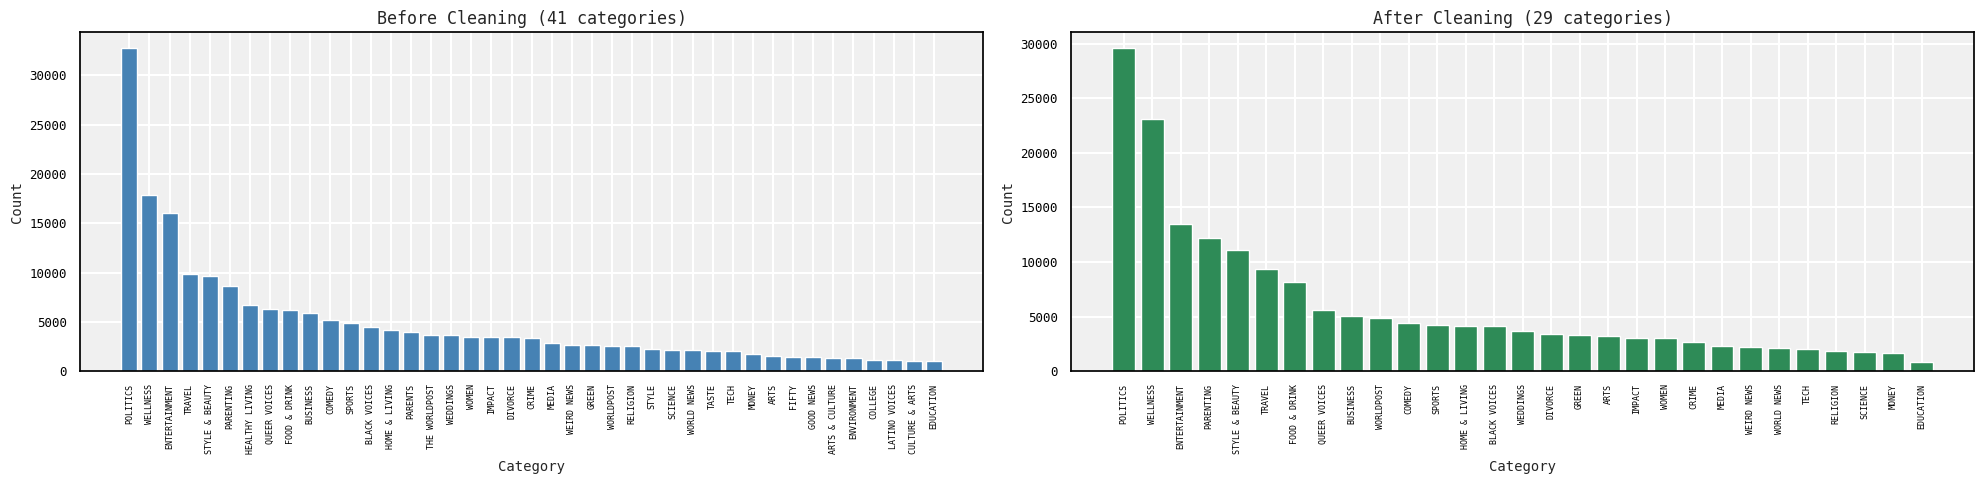


Cleaning Summary:
  Original rows:       200,853
  Final rows:          176,731
  Original categories: 41
  Final categories:    29
Text length (words) stats:
  Min:    4
  Max:    246
  Mean:   32.4
  Median: 30 words
  50th percentile: 30 words
  75th percentile: 37 words
  90th percentile: 51 words
  95th percentile: 57 words
  99th percentile: 68 words


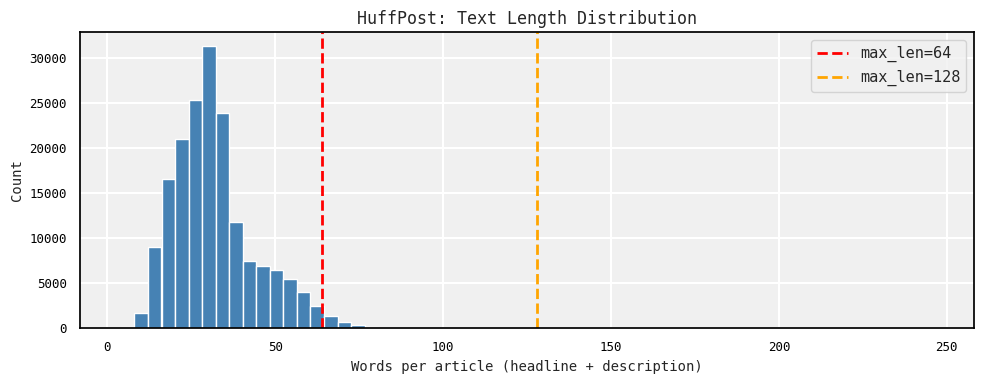


Truncation rate at candidate max_text_lengths:
  max_len=32    truncation rate: 40.5%
  max_len=64    truncation rate: 1.6%
  max_len=128   truncation rate: 0.1%
  max_len=256   truncation rate: 0.0%


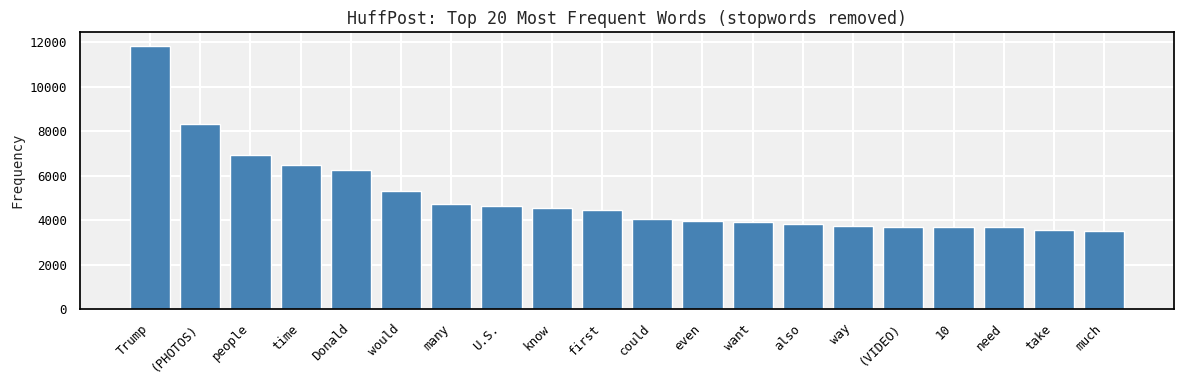

# of classes: 29
{'ARTS': 0, 'BLACK VOICES': 1, 'BUSINESS': 2, 'COMEDY': 3, 'CRIME': 4, 'DIVORCE': 5, 'EDUCATION': 6, 'ENTERTAINMENT': 7, 'FOOD & DRINK': 8, 'GREEN': 9, 'HOME & LIVING': 10, 'IMPACT': 11, 'MEDIA': 12, 'MONEY': 13, 'PARENTING': 14, 'POLITICS': 15, 'QUEER VOICES': 16, 'RELIGION': 17, 'SCIENCE': 18, 'SPORTS': 19, 'STYLE & BEAUTY': 20, 'TECH': 21, 'TRAVEL': 22, 'WEDDINGS': 23, 'WEIRD NEWS': 24, 'WELLNESS': 25, 'WOMEN': 26, 'WORLD NEWS': 27, 'WORLDPOST': 28}
labels_list sample: ['ARTS', 'BLACK VOICES', 'BUSINESS', 'COMEDY', 'CRIME']
Total classes: 29


In [ ]:
# ============================================================
# STEP 1: Convert to Pandas + Save Original Counts
# ============================================================
df = huff_all.to_pandas()
original_counts = df["category"].value_counts()  # save original category distribution BEFORE any cleaning -

# ============================================================
# STEP 2: Remove Exact Duplicates
# ============================================================
before = len(df)
# Remove duplicates based on full "text" column (headline + description)
df = df.drop_duplicates(subset="text")
print(f"Duplicates removed: {before - len(df):,}")
print(f"Rows after dedup:   {len(df):,}")

# ============================================================
# STEP 3: Drop Missing Descriptions
# ============================================================
before = len(df)

# Keep only rows where description is not empty
df = df[df["short_description"].str.strip() != ""]
print(f"Missing descriptions dropped: {before - len(df):,}")
print(f"Rows after drop:              {len(df):,}")

# ============================================================
# STEP 4: Merge Overlapping Categories (41 → 33)
# ============================================================
MERGE_MAP = {
    "HEALTHY LIVING" : "WELLNESS",
    "ARTS & CULTURE" : "ARTS",
    "CULTURE & ARTS" : "ARTS",
    "TASTE"          : "FOOD & DRINK",
    "THE WORLDPOST"  : "WORLDPOST",
    "PARENTS"        : "PARENTING",
    "ENVIRONMENT"    : "GREEN",
    "STYLE"          : "STYLE & BEAUTY",
}
df["category"] = df["category"].replace(MERGE_MAP)
print(f"\nCategories after merging: {df['category'].nunique()}")

# ============================================================
# STEP 5: Drop Tiny Categories (33 -> 29)
# ============================================================

# Tiny classes cause imbalance → model struggles to learn them.

DROP_CATS = ["GOOD NEWS", "FIFTY", "COLLEGE", "LATINO VOICES"]
before = len(df)

# Remove rows belonging to small categories
df = df[~df["category"].isin(DROP_CATS)]
print(f"Rows dropped (tiny cats): {before - len(df):,}")
print(f"Final categories:         {df['category'].nunique()}")
print(f"Final rows:               {len(df):,}")

# ============================================================
# STEP 6: Before vs After Class Distribution Plot
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(20, 5))

# Before — use saved original_counts (no second conversion!)
axes[0].bar(original_counts.index, original_counts.values, color="steelblue")
axes[0].set_title("Before Cleaning (41 categories)")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=90, labelsize=6)

# After — cleaned df
after_counts = df["category"].value_counts()
axes[1].bar(after_counts.index, after_counts.values, color="seagreen")
axes[1].set_title(f"After Cleaning ({df['category'].nunique()} categories)")
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=90, labelsize=6)

plt.tight_layout()
plt.show()

print(f"\nCleaning Summary:")
print(f"  Original rows:       {original_counts.values.sum():,}")
print(f"  Final rows:          {len(df):,}")
print(f"  Original categories: 41")
print(f"  Final categories:    {df['category'].nunique()}")

# ============================================
# Text Length Distribution
# ============================================

# Helps decide MAX_LEN for DistilBERT input tokens.

text_lengths = [len(t.split()) for t in df["text"].values]

print(f"Text length (words) stats:")
print(f"  Min:    {min(text_lengths)}")
print(f"  Max:    {max(text_lengths)}")
print(f"  Mean:   {np.mean(text_lengths):.1f}")
print(f"  Median: {int(np.median(text_lengths))} words")
for p in [50, 75, 90, 95, 99]:# Percentiles help decide truncation strategy
    print(f"  {p}th percentile: {int(np.percentile(text_lengths, p))} words")

plt.figure(figsize=(10, 4))
plt.hist(text_lengths, bins=60, color='steelblue', edgecolor='white')

# Reference lines for possible max token lengths
plt.axvline(x=64,  color='red',    linestyle='--', label='max_len=64')
plt.axvline(x=128, color='orange', linestyle='--', label='max_len=128')
plt.title("HuffPost: Text Length Distribution")
plt.xlabel("Words per article (headline + description)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()
#==================================================================
# Truncation rates
#=====================================================================

# To decide best MAX_LEN without losing too much information.

print("\nTruncation rate at candidate max_text_lengths:")
for max_len in [32, 64, 128, 256]:
    truncated = sum(1 for l in text_lengths if l > max_len)
    print(f"  max_len={max_len:<5} truncation rate: {truncated/len(text_lengths)*100:.1f}%")

#==============================================================================
#Remove stop words
#==============================================================================

#nltk.download('stopwords')  # run once if needed

# ============================================
# Top 20 Word Frequency (Stopwords Removed)
# ============================================

nltk.download('stopwords', quiet=True) # Helps understand common words and noise in dataset.

stop_words = set(stopwords.words('english'))

# Add custom dataset-specific stopwords
additional_stopwords = {
    'said','one','new','get','like','will','us',
    'year','week','day','make','may','go','dont',
    'didnt','can','cant','[sep]','--'
}
stop_words.update(additional_stopwords)

all_words = " ".join(df["text"].values).split()
all_words_filtered = [w for w in all_words if w.lower() not in stop_words]

# Word frequency calculation
word_freq  = Counter(all_words_filtered)
top_words  = word_freq.most_common(20) # Get top 20 words
words, freqs = zip(*top_words)

# Plot top words
plt.figure(figsize=(12, 4))
plt.bar(words, freqs, color='steelblue')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.title("HuffPost: Top 20 Most Frequent Words (stopwords removed)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


#====================================================================
# Encode categorical class labels to numerical
#===================================================================
# ML models cannot use text labels directly → need numeric encoding.

labels = sorted(df["category"].unique())
label2id = {label: i for i, label in enumerate(labels)}# Map: label → id

id2label = {i: label for label, i in label2id.items()}# Map: id → label (useful for predictions later)

df["label"] = df["category"].map(label2id)# Create final label column for training

print("# of classes:", len(label2id))
print(label2id)
labels_list = [id2label[i] for i in range(len(label2id))]

print("labels_list sample:", labels_list[:5])
print("Total classes:", len(labels_list))




#### **Cleaning Summary**

| Step | Rows Removed | Reason |
|---|---|---|
| Exact duplicates | 488 | Prevent data leakage |
| Missing descriptions | 19,611 | Insufficient text for classification |
| Category merging | — | Reduced ambiguity (41 → 29) |
| Tiny categories dropped | 4,023 | Too few samples (GOOD NEWS, FIFTY, COLLEGE, LATINO VOICES) |
| **Total removed** | **24,122** | |

**Final dataset: 176,731 articles across 29 clean categories.**  

#### **Text Representation and Class Imbalance**

Train: 123711
Val:   26510
Test:  26510

OVERALL distribution:
ARTS                      :  3219 (1.82%)
BLACK VOICES              :  4118 (2.33%)
BUSINESS                  :  5074 (2.87%)
COMEDY                    :  4417 (2.50%)
CRIME                     :  2674 (1.51%)
DIVORCE                   :  3423 (1.94%)
EDUCATION                 :   892 (0.50%)
ENTERTAINMENT             : 13468 (7.62%)
FOOD & DRINK              :  8156 (4.61%)
GREEN                     :  3364 (1.90%)
HOME & LIVING             :  4160 (2.35%)
IMPACT                    :  3060 (1.73%)
MEDIA                     :  2273 (1.29%)
MONEY                     :  1705 (0.96%)
PARENTING                 : 12164 (6.88%)
POLITICS                  : 29564 (16.73%)
QUEER VOICES              :  5568 (3.15%)
RELIGION                  :  1857 (1.05%)
SCIENCE                   :  1775 (1.00%)
SPORTS                    :  4221 (2.39%)
STYLE & BEAUTY            : 11066 (6.26%)
TECH                      :  2032 (1.15%)
TRAVEL      

/tmp/ipykernel_1636/2675071173.py:82: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(labels, rotation=90)
/tmp/ipykernel_1636/2675071173.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(labels, rotation=90)
/tmp/ipykernel_1636/2675071173.py:99: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(labels, rotation=90)


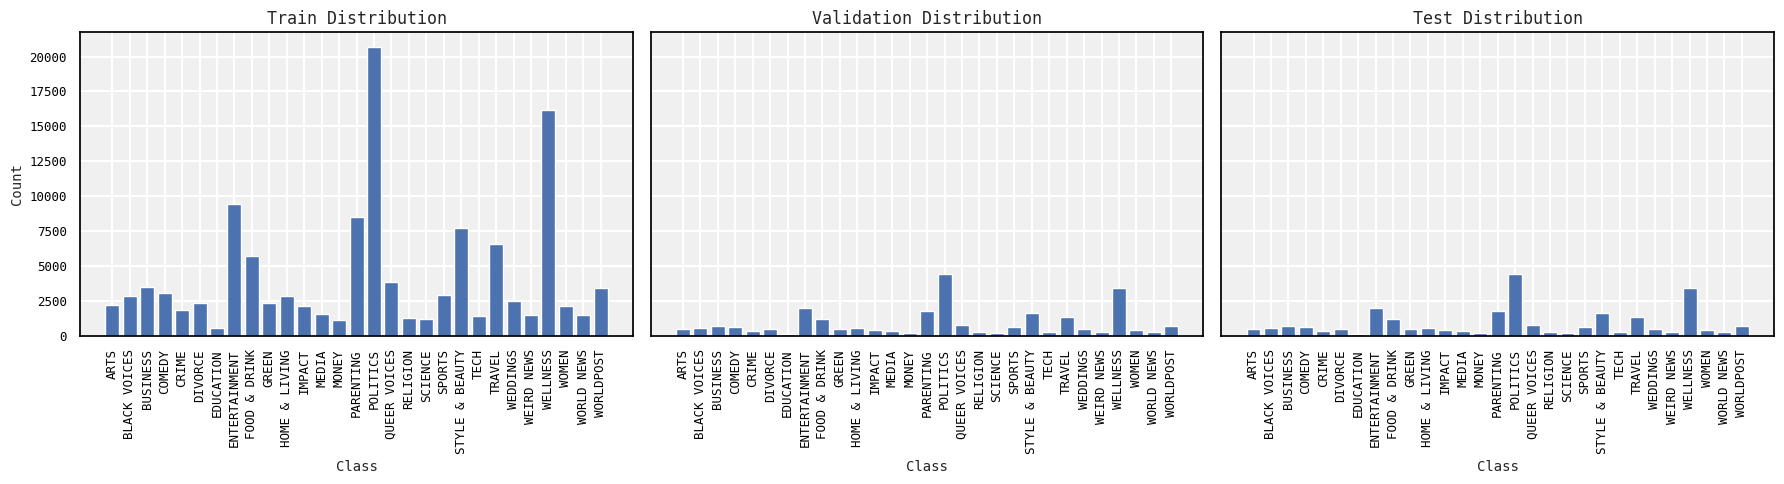


Class Weights:
ARTS                      : 1.8934
BLACK VOICES              : 1.4797
BUSINESS                  : 1.2010
COMEDY                    : 1.3797
CRIME                     : 2.2788
DIVORCE                   : 1.7804
EDUCATION                 : 6.8364
ENTERTAINMENT             : 0.4525
FOOD & DRINK              : 0.7472
GREEN                     : 1.8114
HOME & LIVING             : 1.4649
IMPACT                    : 1.9915
MEDIA                     : 2.6813
MONEY                     : 3.5758
PARENTING                 : 0.5010
POLITICS                  : 0.2061
QUEER VOICES              : 1.0944
RELIGION                  : 3.2815
SCIENCE                   : 3.4347
SPORTS                    : 1.4436
STYLE & BEAUTY            : 0.5507
TECH                      : 2.9999
TRAVEL                    : 0.6480
WEDDINGS                  : 1.6690
WEIRD NEWS                : 2.7593
WELLNESS                  : 0.2640
WOMEN                     : 1.9953
WORLD NEWS                : 2.8028
WORL

In [ ]:
#==================================================================
# Features and target
#====================================================================

#  separate input text (X) and labels (y) for ML training.

X = df["text"].values #input
y = df["label"].values #output

#================================================================
# Stratified data split
#===============================================================

# Ensures each split has SAME class distribution as original dataset.

# Train vs temp (val + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,      # 70% train, 30% temp
    random_state=42,     # reproducibility
    stratify=y           # preserve class distribution
)

# ----------------------------
# STEP 2: Validation vs Test split
# ----------------------------
# Split temp equally → 15% validation, 15% test

# Val vs test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50, # equal split of remaining 30%
    random_state=42,
    stratify=y_temp
)

print("Train:", len(X_train))
print("Val:  ", len(X_val))
print("Test: ", len(X_test))

#====================================================================
# CLASS DISTRIBUTION CHECK
#=====================================================================
# To confirm stratification worked properly.
def show_distribution(y, name):
    """
    Prints class distribution in % and count format.
    Helps verify balanced splits.
    """
    counter = Counter(y)
    total = sum(counter.values())

    print(f"\n{name} distribution:")
    for k, v in sorted(counter.items()):
        print(f"{id2label[k]:25s} : {v:5d} ({v/total:.2%})")

    return counter

overall_dist = show_distribution(y, "OVERALL")
train_dist   = show_distribution(y_train, "TRAIN")
val_dist     = show_distribution(y_val, "VALIDATION")
test_dist    = show_distribution(y_test, "TEST")
#==============================================================
# COMBINED CLASS DISTRIBUTION (1 ROW - 3 PLOTS)
#==============================================================

def plot_all_splits(train_dist, val_dist, test_dist):
    all_classes = sorted(id2label.keys())      # Get sorted class IDs

    labels = [id2label[k] for k in all_classes]

    # Create 1 row, 3 column plots
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)


    # ----------------------------
    # TRAIN DISTRIBUTION
    # ----------------------------
    train_values = [train_dist.get(k, 0) for k in all_classes]
    axes[0].bar(labels, train_values)
    axes[0].set_title("Train Distribution")
    axes[0].set_xticklabels(labels, rotation=90)
    axes[0].set_ylabel("Count")

    # ----------------------------
    # VALIDATION DISTRIBUTION
    # ----------------------------
    val_values = [val_dist.get(k, 0) for k in all_classes]
    axes[1].bar(labels, val_values)
    axes[1].set_title("Validation Distribution")
    axes[1].set_xticklabels(labels, rotation=90)

     # ----------------------------
    # TEST DISTRIBUTION
    # ----------------------------
    test_values = [test_dist.get(k, 0) for k in all_classes]
    axes[2].bar(labels, test_values)
    axes[2].set_title("Test Distribution")
    axes[2].set_xticklabels(labels, rotation=90)

    # Common formatting for all plots
    for ax in axes:
        ax.set_xlabel("Class")

    plt.tight_layout()
    plt.show()

# Call visualisation function
plot_all_splits(train_dist, val_dist, test_dist)

#=========================================================================
#CLASS WEIGHTS (FOR IMBALANCE HANDLING)
#=============================================================================

# Some classes appear more than others → model becomes biased. assign higher weight to rare classes.
class_weights = compute_class_weight(
    class_weight="balanced", # automatically balances based on frequency
    classes=np.unique(y_train),
    y=y_train
)

# Convert to dictionary: class_id → weight
class_weights_dict = {i: w for i, w in enumerate(class_weights)}

# Convert to PyTorch tensor (needed for loss function later)
class_weights_tensor = torch.tensor(
    [class_weights_dict[i] for i in range(len(label2id))],
    dtype=torch.float
)

print("\nClass Weights:")
for k, v in class_weights_dict.items():
    print(f"{id2label[k]:25s} : {v:.4f}")

**Tokenization and PyTorch Dataset Preparation**

The DistilBERT tokenizer converts text into input IDs and attention masks. The tokenized data is then wrapped into PyTorch dataset objects for training, validation, and testing.

In [ ]:
#==============================================================
# TOKENIZATION (DistilBERT)
#==============================================================

# Each text is converted into: - input_ids (token numbers),  - attention_mask (which tokens to attend to)

tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

max_length = 64

train_encodings = tokenizer(list(X_train), truncation=True, padding=True, max_length=max_length) #truncation=True - cut long texts
val_encodings   = tokenizer(list(X_val), truncation=True, padding=True, max_length=max_length) #padding=True, pad short texts
test_encodings  = tokenizer(list(X_test), truncation=True, padding=True, max_length=max_length)

#==============================================================
# DATASET CLASS - PyTorch needs data in (input, label) format for training.
#==============================================================

class NewsDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):          # Convert each feature into PyTorch tensors
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)         # Total number of samples

# Create PyTorch datasets
train_dataset = NewsDataset(train_encodings, y_train)
val_dataset   = NewsDataset(val_encodings, y_val)
test_dataset  = NewsDataset(test_encodings, y_test)

#==============================================================
# STRATIFICATION CHECK (POST-TOKENIZATION VALIDATION)
#==============================================================

# Confirm that train/val/test still maintain class balance.

def show_distribution(y, name):
    counter = Counter(y)
    total = len(y)

    print(f"\n{name} distribution:")
    for k, v in sorted(counter.items()):
        print(f"{id2label[k]:25s} : {v:5d} ({v/total:.2%})")

show_distribution(y_train, "Train")
show_distribution(y_val, "Validation")
show_distribution(y_test, "Test")

#====================================================================================
# sample tokens - (DEBUGGING STEP)
#================================================================================
# Helps verify tokenizer is working correctly

print("####################SAMPLE TOKENS############################")
def inspect_samples(n=5):
    rows = []

    for i in range(n):
        input_ids = train_encodings["input_ids"][i]         # Get token IDs for first sample

        rows.append({
            "Original Text": X_train[i][:120] + "...",             # Show original text (truncated for readability)
            "Token IDs (first 15)": input_ids[:15],            # First 15 token IDs
            "Decoded Tokens": tokenizer.convert_ids_to_tokens(input_ids[:15]),             # Convert token IDs back to readable tokens
            "Label ID": int(y_train[i]),            # Numeric label
            "Category": id2label[int(y_train[i])]             # Human-readable category name

        })

    return pd.DataFrame(rows)

# Display sample inspection table
display(inspect_samples(5))

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


Train distribution:
ARTS                      :  2253 (1.82%)
BLACK VOICES              :  2883 (2.33%)
BUSINESS                  :  3552 (2.87%)
COMEDY                    :  3092 (2.50%)
CRIME                     :  1872 (1.51%)
DIVORCE                   :  2396 (1.94%)
EDUCATION                 :   624 (0.50%)
ENTERTAINMENT             :  9427 (7.62%)
FOOD & DRINK              :  5709 (4.61%)
GREEN                     :  2355 (1.90%)
HOME & LIVING             :  2912 (2.35%)
IMPACT                    :  2142 (1.73%)
MEDIA                     :  1591 (1.29%)
MONEY                     :  1193 (0.96%)
PARENTING                 :  8515 (6.88%)
POLITICS                  : 20695 (16.73%)
QUEER VOICES              :  3898 (3.15%)
RELIGION                  :  1300 (1.05%)
SCIENCE                   :  1242 (1.00%)
SPORTS                    :  2955 (2.39%)
STYLE & BEAUTY            :  7746 (6.26%)
TECH                      :  1422 (1.15%)
TRAVEL                    :  6583 (5.32%)
WEDDINGS    

,Original Text,Token IDs (first 15),Decoded Tokens,Label ID,Category
0,Arianna Huffington Makes The Case For Baby Pho...,"[101, 9342, 9516, 26149, 3084, 1996, 2553, 200...","[[CLS], aria, ##nna, huffington, makes, the, c...",12,MEDIA
1,She Dropped Everything To Come Fight For Immig...,"[101, 2016, 3333, 2673, 2000, 2272, 2954, 2005...","[[CLS], she, dropped, everything, to, come, fi...",15,POLITICS
2,"Decades Of Lifesaving Lessons, One Jump At A T...","[101, 5109, 1997, 2166, 3736, 6455, 8220, 1010...","[[CLS], decades, of, life, ##sa, ##ving, lesso...",25,WELLNESS
3,A Different Kind Of Cruise Line [SEP] Larry Pi...,"[101, 1037, 2367, 2785, 1997, 8592, 2240, 102,...","[[CLS], a, different, kind, of, cruise, line, ...",22,TRAVEL
4,Dog Knows The Difference Between 'Bath' And 'W...,"[101, 3899, 4282, 1996, 4489, 2090, 1005, 7198...","[[CLS], dog, knows, the, difference, between, ...",3,COMEDY


#### **Model Selection and Training**

In [ ]:
# ============================================
# Hyperparameters — all defined in A.1 globals
# ============================================
# Restate here for clarity

LEARNING_RATE = 2e-5   # AdamW standard for DistilBERT fine-tuning
BATCH_SIZE    = 32     # fits in Colab GPU memory
EPOCHS        = 25     # max; early stopping will cut short
DROPOUT_RATE  = 0.3    # DistilBERT default
WEIGHT_DECAY  = 0.01   # AdamW regularization
MAX_LEN       = 64     # covers 98.4% of articles
NUM_CLASSES   = len(label2id)  # dynamic — 29 after cleaning

print("Hyperparameters:")
print(f"  Learning Rate : {LEARNING_RATE}")
print(f"  Batch Size    : {BATCH_SIZE}")
print(f"  Max Epochs    : {EPOCHS}")
print(f"  Dropout       : {DROPOUT_RATE}")
print(f"  Weight Decay  : {WEIGHT_DECAY}")
print(f"  Max Length    : {MAX_LEN}")
print(f"  Num Classes   : {NUM_CLASSES}")

Hyperparameters:
  Learning Rate : 2e-05
  Batch Size    : 32
  Max Epochs    : 25
  Dropout       : 0.3
  Weight Decay  : 0.01
  Max Length    : 64
  Num Classes   : 29


In [ ]:
# ============================================
# DataLoaders — using datasets from A.1
# already created in A.1.3.5
# ============================================


# ============================================
# TRAIN DATA LOADER
# ============================================
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE, # number of samples per batch
    shuffle=True           # shuffle helps prevent learning order bias
)

# ============================================
# VALIDATION DATA LOADER
# ============================================
val_loader = DataLoader(
    val_dataset,           # validation dataset
    batch_size=BATCH_SIZE, # same batch size for consistency
    shuffle=False          # no shuffling needed for evaluation
)
# ============================================
# TEST DATA LOADER
# ============================================
test_loader = DataLoader(
    test_dataset,          # test dataset
    batch_size=BATCH_SIZE, # same batch size
    shuffle=False          # keep order fixed for final evaluation
)


# Ensures batching is correctly applied and dataset is split properly.SANITY CHECK :Number of batches

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

Train batches : 3866
Val batches   : 829
Test batches  : 829


In [ ]:

# ============================================
# DISTILBERT MODEL SETUP (FULL FINE-TUNING)
# ============================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Training on GPU is much faster than CPU if available.
print(f"Using device: {device}")

# ============================================
# MODEL CONFIGURATION
# ============================================
# It defines model architecture + training behavior (like number of labels, dropout)

config = DistilBertConfig.from_pretrained(
    "distilbert-base-uncased",   # base pretrained model
    num_labels=NUM_CLASSES,      # number of output classes
    #### done below to avoid overfitting
    #dropout=DROPOUT_RATE,        # dropout for hidden layers (regularization)
    #attention_dropout=DROPOUT_RATE  # dropout in attention layers

    # added below to avoid overfitting
    dropout=0.3,           # increased from 0.1
    attention_dropout=0.2
    )


# ============================================
# LOAD PRETRAINED MODEL
# ============================================
#  load DistilBERT with a classification head.This converts transformer outputs → class predictions
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    config=config
)


# ============================================
# FREEZE / UNFREEZE PARAMETERS
# ============================================
# Unfreeze all layers-FULL fine-tuning → model learns task-specific patterns
for param in model.parameters():
    param.requires_grad = True

# ============================================
# MOVE MODEL TO DEVICE (GPU/CPU)
# ============================================
model = model.to(device)

# ============================================
# COUNT TRAINABLE PARAMETERS
# ============================================
# Helps understand model complexity and training cost

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Trainable parameters: {trainable_params:,}")
print("Model ready for full fine-tuning")

Using device: cuda


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable parameters: 66,975,773
Model ready for full fine-tuning


In [ ]:
# ============================================
# OPTIMIZER + LOSS FUNCTION SETUP
# ============================================
# - Optimizer controls how model learns (updates weights)
# - Loss function measures prediction error
# - Class weights help handle class imbalance
# ADAMW OPTIMIZER - Works very well with Transformers like DistilBERT , Adds weight decay properly (better regularization than Adam)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)
# ============================================
# CLASS WEIGHTS → PYTORCH TENSOR
# ============================================
# Some classes appear more frequently than others. Without weights, model will bias toward majority classes.
class_weights_tensor = torch.tensor(
    [class_weights_dict[i] for i in range(NUM_CLASSES)],
    dtype=torch.float
).to(device)  # move to GPU/CPU same as model

# ============================================
# LOSS FUNCTION (WEIGHTED CROSS ENTROPY)
# ============================================
# - Standard loss for multi-class classification. Works with logits directly (no softmax needed)
# Weighted - Penalizes mistakes on rare classes more heavily  and  Improves performance on imbalanced dataset

#criterion = nn.CrossEntropyLoss(weight=class_weights_tensor) - to void overfiting
criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor,
    label_smoothing=0.1
)



# ============================================
# SUMMARY PRINT (FOR DEBUGGING / REPORT)
# ============================================
print("Optimizer : AdamW")
print(f"  lr={LEARNING_RATE}, weight_decay={WEIGHT_DECAY}")
print("Loss      : CrossEntropyLoss with class weights")
print("Optimizer + loss configured successfully → training ready ")

Optimizer : AdamW
  lr=2e-05, weight_decay=0.01
Loss      : CrossEntropyLoss with class weights
Optimizer + loss configured successfully → training ready 


To address severe class imbalance in the HuffPost dataset, I applied class-weighted cross-entropy loss. This ensures minority classes contribute more significantly to the loss function, improving macro-F1 performance. Optimization was performed using AdamW with a learning rate of 2e-5 and weight decay of 0.01, consistent with best practices for transformer fine-tuning.

In [ ]:
# ============================================
# LEARNING RATE SCHEDULER (ReduceLROnPlateau)
# ============================================
# - Helps improve training stability
# - Automatically reduces learning rate when model stops improving
# - Prevents getting stuck at suboptimal solutions
'''
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,   # optimizer whose learning rate will be adjusted

    mode="min",  # MINIMIZE validation loss

    factor=0.5,   # reduce learning rate by half when triggered

    patience=1    # wait 1 epoch with no improvement before reducing LR
)'''

# If validation loss does NOT improve for 'patience' epochs: → learning rate = learning rate × factor
# Example:# 1e-5 → 5e-6 → 2.5e-6 → ...
# This helps model: escape plateaus &  fine-tune more carefully in later stages


# To avoid overfittin
from transformers import get_linear_schedule_with_warmup

total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),  # 10% warmup
    num_training_steps=total_steps
)

In [ ]:
# ============================================
# MIXED PRECISION TRAINING (AMP SETUP)
# ============================================
# Why AMP (Automatic Mixed Precision)? Speeds up training on GPU, Reduces memory usage and Maintains near full precision accuracy
# GradScaler helps prevent numerical underflow in float16 training

scaler = torch.amp.GradScaler(device="cuda")

# ============================================
# EARLY STOPPING SETUP - Prevents overfitting & Stops training when validation loss stops improving
# ============================================

#patience = 3 - to avoid over fitting
patience = 2

best_val_acc = 0.0   # change early stopping to monitor val_acc
best_val_f1 = 0.0
patience_counter = 0
best_weights = None

# ============================================
# TRAINING HISTORY TRACKING - Used for plotting loss/accuracy curves later
# ============================================

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "val_f1": [],
}

# Start timer (for reporting training duration)
start_time = time.time()

# ============================================
# MAIN TRAINING LOOP
# ============================================

for epoch in range(EPOCHS):

    # ---------------- TRAINING phase ----------------
    model.train()  # enables dropout, batchnorm updates
    total_loss, correct, total = 0, 0, 0

    for batch in train_loader:
        # Move data to GPU/CPU
        input_ids      = batch["input_ids"].to(device, non_blocking=True)
        attention_mask = batch["attention_mask"].to(device, non_blocking=True)
        labels_batch   = batch["labels"].to(device, non_blocking=True)

        # Reset gradients
        optimizer.zero_grad()

        # ---------------- FORWARD PASS (AMP enabled) ----------------
        with torch.amp.autocast(device_type="cuda"):
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            # Compute weighted loss
            loss = criterion(outputs.logits, labels_batch)

        # ---------------- BACKWARD PASS ----------------

        scaler.scale(loss).backward()    # scaled gradients for stability
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)        # optimizer step
        scaler.update()                # update scaler
        scheduler.step()   # ← ADD THIS LINE to avoid overfitting

        # Track training loss
        total_loss += loss.item()
        preds = outputs.logits.argmax(dim=1)  # Predictions

        # Accuracy computation
        correct += (preds == labels_batch).sum().item()
        total   += labels_batch.size(0)

    train_loss = total_loss / len(train_loader)
    train_acc  = correct / total

    # ---------------- VALIDATION phase ----------------
    model.eval()
    val_loss_total, val_correct, val_total = 0, 0, 0
    val_preds_all, val_labels_all = [], []

    with torch.inference_mode():  # faster + no gradients
        for batch in val_loader:
            input_ids      = batch["input_ids"].to(device, non_blocking=True)
            attention_mask = batch["attention_mask"].to(device, non_blocking=True)
            labels_batch   = batch["labels"].to(device, non_blocking=True)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            # Compute validation loss
            loss = criterion(outputs.logits, labels_batch)

            val_loss_total += loss.item()
            preds           = outputs.logits.argmax(dim=1)
            val_correct    += (preds == labels_batch).sum().item()
            val_total      += labels_batch.size(0)
            val_preds_all.extend(preds.cpu().numpy())
            val_labels_all.extend(labels_batch.cpu().numpy())

    # Average validation metrics
    val_loss = val_loss_total / len(val_loader)
    val_acc  = val_correct / val_total
    val_f1   = f1_score(val_labels_all, val_preds_all, average="macro")

    # ---------------- LEARNING RATE SCHEDULER ----------------
    # Adjust LR based on validation loss
    #scheduler.step(val_loss) - to avoid overfitting

    #scheduler.step()   # warmup scheduler steps per batch, not per epoch


    # ---------------- HISTORY ----------------
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    # Print epoch summary
    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
          f"Val F1: {val_f1:.4f}")

    # ============================================
    # EARLY STOPPING (MONITORING F1 SCORE)
    # ============================================
    if val_f1 > best_val_f1:
        best_val_f1   = val_f1
        best_weights  = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
        print(f"  ✓ Best model saved at epoch {epoch+1}  val_f1={val_f1:.4f}")
    else:
        patience_counter += 1
        print(f"  No improvement ({patience_counter}/{patience})")
        if patience_counter >= patience:
            print("Early stopping triggered!")
            break

# ============================================
# RESTORE BEST MODEL
# ============================================
model.load_state_dict(best_weights)

total_time = time.time() - start_time
best_epoch = int(np.argmax(history["val_acc"])) + 1

# ============================================
# TRAINING SUMMARY TABLE
# ============================================
print("=" * 50)
print(f"Training complete")
print(f"\n{'='*75}")
print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>10} | {'Val Loss':>10} | {'Val Acc':>10}| {'Val F1':>10}")
print("-" * 75)

for ep, (tl, ta, vl, va, vf) in enumerate(zip(
        history["train_loss"], history["train_acc"],
        history["val_loss"],   history["val_acc"],history["val_f1"]), 1):

    marker = " ← best" if ep == best_epoch else ""
    print(f"{ep:>2} | {tl:.4f} | {ta:.4f} | {vl:.4f} | {va:.4f}{marker}")

print("=" * 75)
print(f"\nBest epoch (highest val accuracy): {best_epoch}")
print(f"  Val Acc  at best epoch : {history['val_acc'][best_epoch-1]:.4f}")
print(f"  Val F1   at best epoch : {history['val_f1'][best_epoch-1]:.4f}")
print(f"  Train Loss at best     : {history['train_loss'][best_epoch-1]:.4f}")
print(f"  Train Acc at best      : {history['train_acc'][best_epoch-1]:.4f}")

Epoch 1/25 | Train Loss: 2.9853 | Train Acc: 0.3646 | Val Loss: 2.1322 | Val Acc: 0.6108 | Val F1: 0.5252
  ✓ Best model saved at epoch 1  val_f1=0.5252
Epoch 2/25 | Train Loss: 2.0567 | Train Acc: 0.6288 | Val Loss: 1.9384 | Val Acc: 0.6673 | Val F1: 0.5978
  ✓ Best model saved at epoch 2  val_f1=0.5978
Epoch 3/25 | Train Loss: 1.8941 | Train Acc: 0.6781 | Val Loss: 1.9044 | Val Acc: 0.6946 | Val F1: 0.6228
  ✓ Best model saved at epoch 3  val_f1=0.6228
Epoch 4/25 | Train Loss: 1.7641 | Train Acc: 0.7167 | Val Loss: 1.8647 | Val Acc: 0.7014 | Val F1: 0.6386
  ✓ Best model saved at epoch 4  val_f1=0.6386
Epoch 5/25 | Train Loss: 1.6591 | Train Acc: 0.7460 | Val Loss: 1.8750 | Val Acc: 0.7038 | Val F1: 0.6385
  No improvement (1/2)
Epoch 6/25 | Train Loss: 1.5715 | Train Acc: 0.7726 | Val Loss: 1.8870 | Val Acc: 0.7201 | Val F1: 0.6523
  ✓ Best model saved at epoch 6  val_f1=0.6523
Epoch 7/25 | Train Loss: 1.5037 | Train Acc: 0.7973 | Val Loss: 1.9386 | Val Acc: 0.7126 | Val F1: 0.6444


#### **Model Selection Summary**

DistilBERT full fine-tuning was selected because it performed better than earlier baseline models. Full fine-tuning allowed the transformer layers to adapt to HuffPost-specific text, while dropout, label smoothing, warmup scheduling, gradient clipping, mixed precision training, and early stopping helped control overfitting.

#### **Evaluation and Error Analysis**
The model is evaluated using accuracy, macro F1, weighted F1, Top-3 accuracy, confusion matrix, and per-class F1 scores. Macro F1 is important because the dataset is imbalanced.

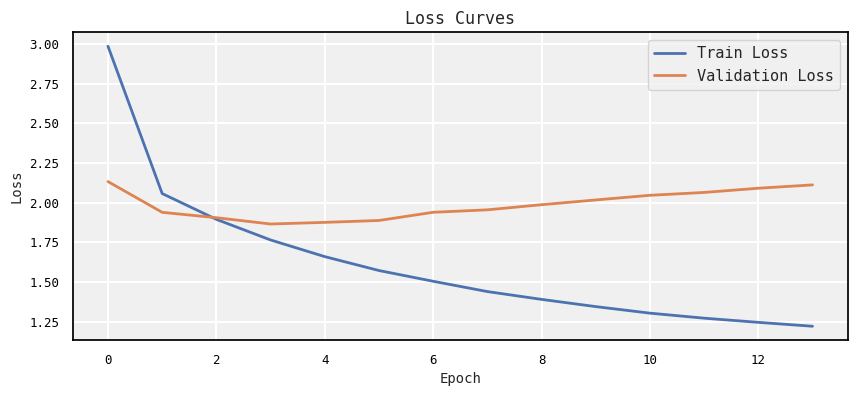

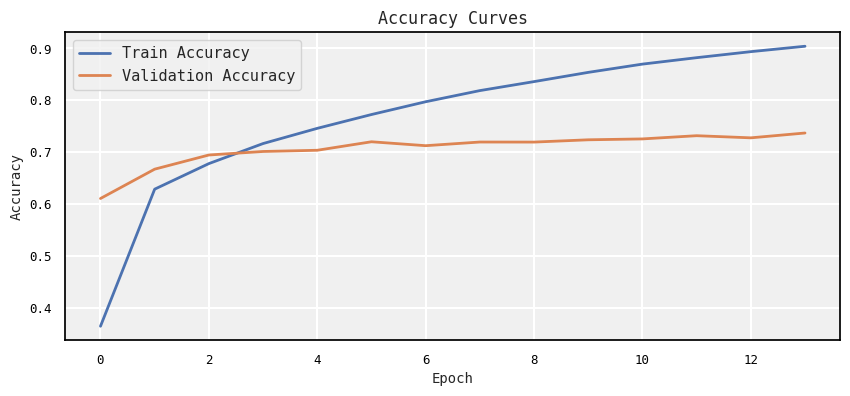

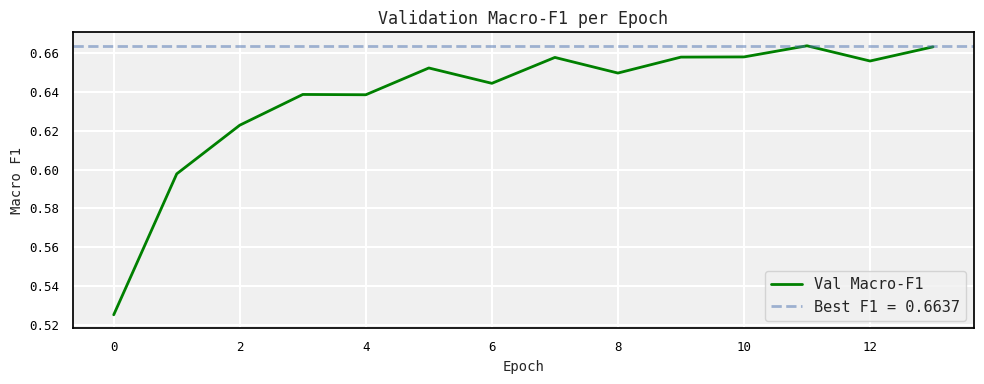

In [ ]:
# Loss curves
plt.figure(figsize=(10,4))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.title("Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Accuracy curves
plt.figure(figsize=(10,4))
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")
plt.title("Accuracy Curves")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Macro-F1 curves
plt.figure(figsize=(10, 4))
plt.plot(history["val_f1"], label="Val Macro-F1", color="green")
plt.axhline(y=max(history["val_f1"]), linestyle="--", alpha=0.5,
            label=f"Best F1 = {max(history['val_f1']):.4f}")
plt.title("Validation Macro-F1 per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.legend()
plt.tight_layout()
plt.show()

Test Accuracy  : 0.7302150132025651
Macro F1       : 0.6623897626806629
Weighted F1    : 0.7366204011226426


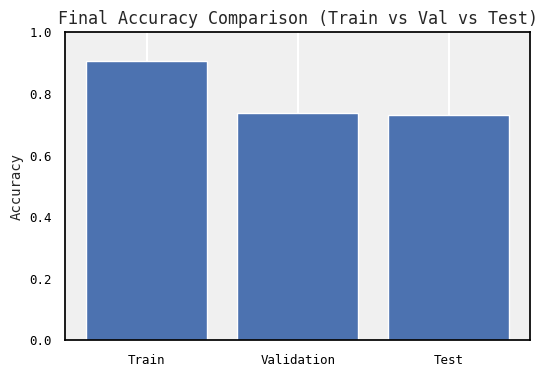

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

# ============================================
# SET MODEL TO EVALUATION MODE
# ============================================
# - Turns off dropout
# - Ensures deterministic predictions

model.eval()

# Store predictions and true labels
all_preds, all_labels = [], []
correct_top3 = 0

# ============================================
# INFERENCE ON TEST SET
# ============================================
# - Saves memory
# - Speeds up inference
# - No gradient computation needed
with torch.no_grad():
    for batch in test_loader:

        # Move inputs to device
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels_batch = batch["labels"].to(device)

        # Forward pass (no training)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = outputs.logits.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels_batch.cpu().numpy())
           # ── Top-3 in same pass — no second loop needed ────────
        probs = torch.softmax(outputs.logits, dim=1)
        top3  = torch.topk(probs, k=3, dim=1).indices
        for i in range(len(labels_batch)):
            if labels_batch[i] in top3[i]:
                correct_top3 += 1
# ============================================
# EVALUATION METRICS
# ============================================
# Accuracy = overall correctness
# Macro F1 = treats all classes equally (important for imbalance)
# Weighted F1 = accounts for class frequency

acc = accuracy_score(all_labels, all_preds)
macro_f1 = f1_score(all_labels, all_preds, average="macro")
weighted_f1 = f1_score(all_labels, all_preds, average="weighted")

print("Test Accuracy  :", acc)
print("Macro F1       :", macro_f1)
print("Weighted F1    :", weighted_f1)


plt.figure(figsize=(6,4))

plt.bar(
    ["Train", "Validation", "Test"],
    [history["train_acc"][-1], history["val_acc"][-1], acc]
)

plt.title("Final Accuracy Comparison (Train vs Val vs Test)")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.show()

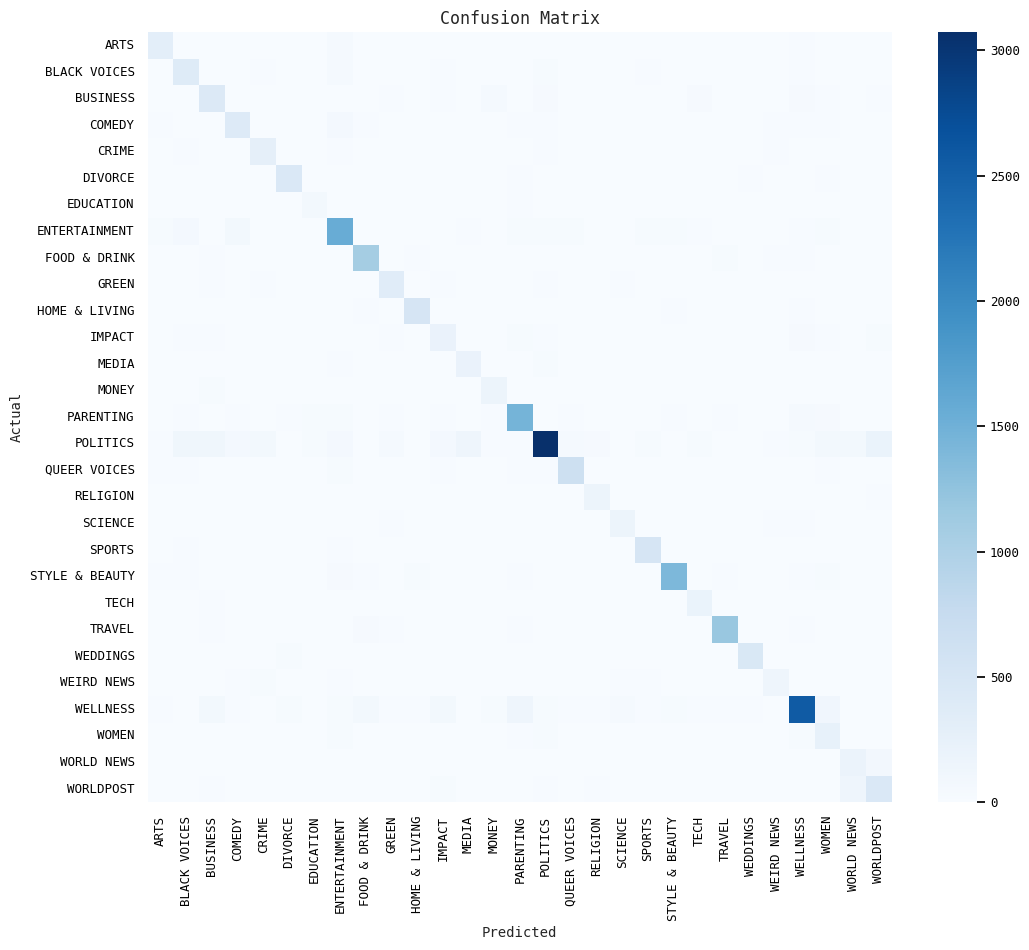

In [ ]:
# ============================================
# CONFUSION MATRIX (MODEL ERROR ANALYSIS)
# ============================================
# Why is this important?
# - Shows exactly where the model is making mistakes
# - Helps identify which classes are confused with each other
# - Much more informative than accuracy alone


cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap="Blues", xticklabels=labels_list, yticklabels=labels_list)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

,precision,recall,f1-score,support
STYLE & BEAUTY,0.894602,0.838554,0.865672,1660.000000
TRAVEL,0.870168,0.846099,0.857965,1410.000000
FOOD & DRINK,0.827718,0.883170,0.854545,1224.000000
WEDDINGS,0.847273,0.851920,0.849590,547.000000
HOME & LIVING,0.819033,0.841346,0.830040,624.000000
DIVORCE,0.790123,0.871595,0.828862,514.000000
WELLNESS,0.862765,0.740901,0.797203,3462.000000
PARENTING,0.776477,0.799890,0.788010,1824.000000
POLITICS,0.896934,0.692672,0.781679,4435.000000
SPORTS,0.744589,0.815166,0.778281,633.000000


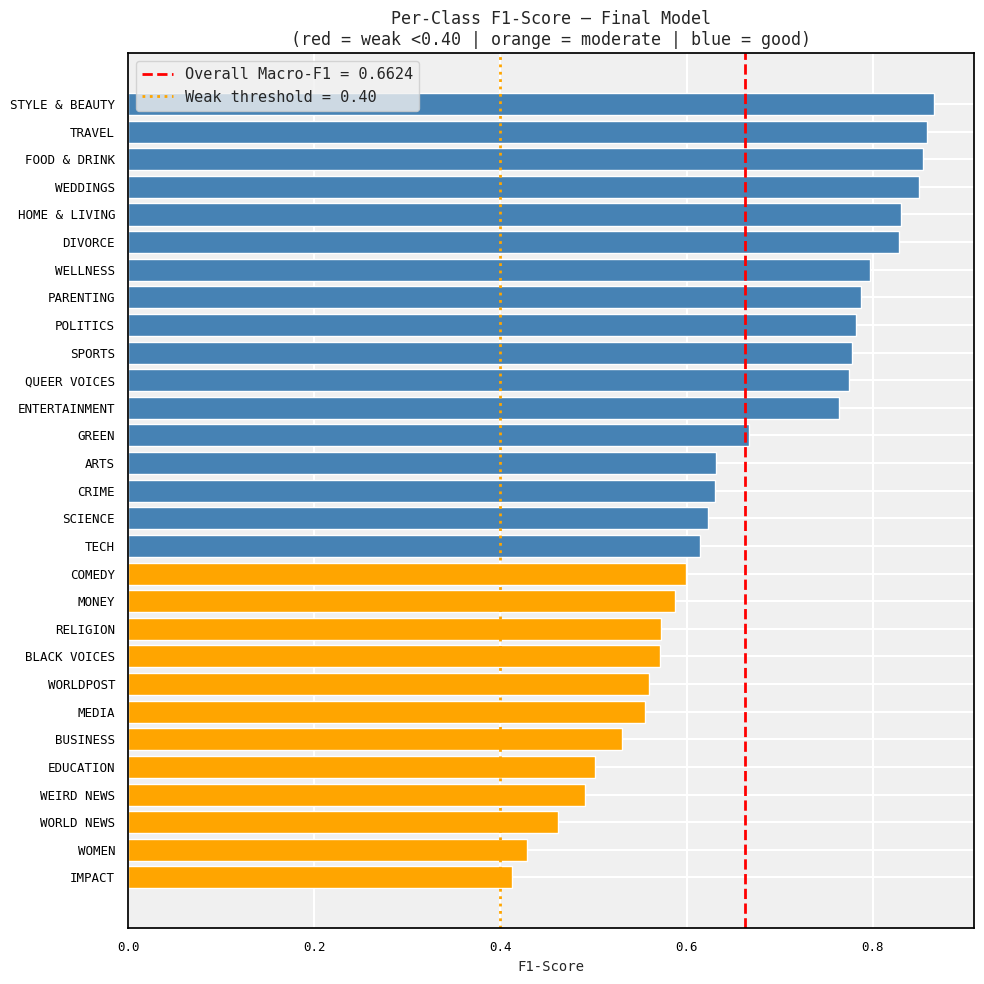

In [ ]:
# ============================================
# DETAILED CLASSIFICATION REPORT (PER-CLASS METRICS)
# ============================================
# - Accuracy alone is not enough for imbalanced datasets
# -  need precision, recall, and F1-score for each class
# - Helps understand which categories the model performs well/poorly on

report_dict = classification_report(all_labels, all_preds,
                                    target_names=labels_list,
                                    output_dict=True)

# ============================================
# CONVERT REPORT → DATAFRAME
# ============================================
# - Easier to analyze
# - Easier to sort, filter, and visualize
df_report = pd.DataFrame(report_dict).transpose()

# Sort by F1-score (best to worst performing classes)
df_report = df_report.sort_values("f1-score", ascending=False)
display(df_report)

# ============================================================
# BAR CHART — Macro-F1 per class (sorted best to worst)
# Shows visually which categories model handles well vs poorly
# ============================================================

# Extract only real class rows (drop macro avg, weighted avg etc.)
df_classes = df_report.drop(
    ["accuracy", "macro avg", "weighted avg"],
    errors="ignore"
).copy()

df_classes = df_classes.sort_values("f1-score", ascending=True)

plt.figure(figsize=(10, 10))
colors = [
    "tomato" if v < 0.40 else
    "orange" if v < 0.60 else
    "steelblue"
    for v in df_classes["f1-score"]
]
plt.barh(df_classes.index, df_classes["f1-score"], color=colors)
plt.axvline(x=macro_f1, color="red", linestyle="--",
            label=f"Overall Macro-F1 = {macro_f1:.4f}")
plt.axvline(x=0.40, color="orange", linestyle=":",
            label="Weak threshold = 0.40")
plt.xlabel("F1-Score")
plt.title("Per-Class F1-Score — Final Model\n"
          "(red = weak <0.40 | orange = moderate | blue = good)")
plt.legend()
plt.tight_layout()
plt.show()

Top-3 Accuracy: 0.8881931346661637
  Top-3 Accuracy  : 0.8882


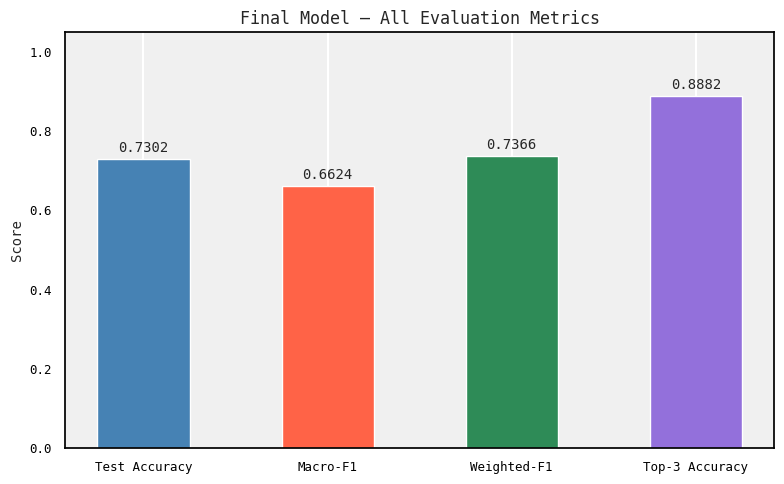


        FINAL RESULTS SUMMARY
  Dataset         : HuffPost News (cleaned)
  Classes         : 29
  Train samples   : 123,711
  Val samples     : 26,510
  Test samples    : 26,510
  Best epoch      : 14 / 14
  Training time   : 01:18:03
------------------------------------------------------------
  Test Accuracy   : 0.7302
  Macro F1        : 0.6624
  Weighted F1     : 0.7366
  Top-3 Accuracy  : 0.8882


In [ ]:
# ============================================
# TOP-3 ACCURACY EVALUATION
# ============================================
# - Standard accuracy checks only top prediction
# - Top-3 checks if correct label is within top 3 predictions
# - Useful for multi-class NLP where classes are semantically similar



# Top-3 already computed in A.3.3 — no second loop needed
top3_acc = correct_top3 / len(all_labels)
print("Top-3 Accuracy:", top3_acc)


# Compute final Top-3 accuracy
print(f"  Top-3 Accuracy  : {top3_acc:.4f}")

# ============================================================
# SUMMARY BAR CHART — All key metrics side by side
# ============================================================
metrics      = ["Test Accuracy", "Macro-F1", "Weighted-F1", "Top-3 Accuracy"]
values       = [acc, macro_f1, weighted_f1, top3_acc]
colors_bars  = ["steelblue", "tomato", "seagreen", "mediumpurple"]

plt.figure(figsize=(8, 5))
bars = plt.bar(metrics, values, color=colors_bars, width=0.5)

# Add value labels on top of each bar
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.01,
             f"{val:.4f}",
             ha="center", va="bottom", fontsize=10)

plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Final Model — All Evaluation Metrics")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

# - Gives a clean executive summary of entire project

print("\n" + "="*60)
print("        FINAL RESULTS SUMMARY")
print("="*60)
print(f"  Dataset         : HuffPost News (cleaned)")
print(f"  Classes         : {NUM_CLASSES}")
print(f"  Train samples   : {len(X_train):,}")
print(f"  Val samples     : {len(X_val):,}")
print(f"  Test samples    : {len(X_test):,}")
print(f"  Best epoch      : {best_epoch} / {len(history['train_loss'])}")
print(f"  Training time   : {format_hms(total_time)}")
print("-"*60)
print(f"  Test Accuracy   : {acc:.4f}")
print(f"  Macro F1        : {macro_f1:.4f}")
print(f"  Weighted F1     : {weighted_f1:.4f}")
print(f"  Top-3 Accuracy  : {top3_acc:.4f}")
print("="*60)



#### **Real-World Inference Test**

This section tests the trained model on new example headlines that were not part of the HuffPost dataset.

In [ ]:

def predict_category(text, model, tokenizer, id2label, device, top_k=3):
    """
    Predict category for a single new headline.
    Returns top-k predictions with confidence scores.
    """
    model.eval()
    encoding = tokenizer(
        text,
        truncation=True,
        padding=True,
        max_length=64,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = model(**encoding)
        probs = torch.softmax(outputs.logits, dim=1)[0]
        top_probs, top_ids = torch.topk(probs, k=top_k)

    results = []
    for prob, idx in zip(top_probs, top_ids):
        results.append({
            "category": id2label[idx.item()],
            "confidence": round(prob.item(), 4)
        })
    return results


# ============================================
# TEST WITH BRAND NEW HEADLINES
# These are NOT from HuffPost dataset
# ============================================

new_headlines = [
    # Clear cases — model should be confident
    "Scientists discover new planet in solar system",
    "Stock market hits record high amid inflation fears",
    "New vegan restaurant opens in downtown Manhattan",
    "NBA finals: Lakers defeat Celtics in overtime thriller",
    "Taylor Swift announces new world tour dates",

    # Harder cases — semantically overlapping
    "Why more women are leaving corporate America",
    "How meditation changed my mental health journey",
    "UN calls for ceasefire as conflict spreads globally",
    "Congress debates new climate change legislation",
    "Is social media making teenagers more anxious",
]

# ============================================
# RUN PREDICTIONS
# ============================================
print("=" * 65)
print("REAL-WORLD INFERENCE TEST — New Unseen Headlines")
print("=" * 65)

for headline in new_headlines:
    preds = predict_category(
        headline, model, tokenizer, id2label, device, top_k=3
    )
    print(f"\nHeadline : {headline}")
    for i, p in enumerate(preds, 1):
        print(f"  Top-{i}  : {p['category']:25s} ({p['confidence']*100:.1f}%)")
print("=" * 65)

REAL-WORLD INFERENCE TEST — New Unseen Headlines

Headline : Scientists discover new planet in solar system
  Top-1  : SCIENCE                   (97.8%)
  Top-2  : EDUCATION                 (0.3%)
  Top-3  : WORLD NEWS                (0.2%)

Headline : Stock market hits record high amid inflation fears
  Top-1  : MONEY                     (94.7%)
  Top-2  : BUSINESS                  (2.6%)
  Top-3  : EDUCATION                 (0.4%)

Headline : New vegan restaurant opens in downtown Manhattan
  Top-1  : BUSINESS                  (29.8%)
  Top-2  : FOOD & DRINK              (23.7%)
  Top-3  : EDUCATION                 (5.7%)

Headline : NBA finals: Lakers defeat Celtics in overtime thriller
  Top-1  : SPORTS                    (94.6%)
  Top-2  : EDUCATION                 (0.8%)
  Top-3  : SCIENCE                   (0.4%)

Headline : Taylor Swift announces new world tour dates
  Top-1  : ENTERTAINMENT             (73.9%)
  Top-2  : EDUCATION                 (3.4%)
  Top-3  : MONEY       

#### **Conclusion and Future Work**

The final DistilBERT model achieved strong performance for a 29-class short-text classification problem.

#### Final Results

| Metric | Score |
|---|---:|
| Test Accuracy | 0.7302 |
| Macro F1 | 0.6624 |
| Weighted F1 | 0.7366 |
| Top-3 Accuracy | 0.8882 |

#### Key Learnings

- Data cleaning and label refinement improved the classification task.
- Macro F1 was more useful than accuracy because the dataset was imbalanced.
- DistilBERT performed well on short news text.
- Overlapping categories remained the main source of error.

#### Future Work

- Merge additional overlapping labels such as WORLDPOST and WORLD NEWS
- Try focal loss for minority classes
- Add author or date as additional features
- Use data augmentation for smaller categories
- Compare with RoBERTa or larger transformer models
- Deploy the model as a simple API or web app